In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

%pip install imbalanced-learn
%pip install langchain
%pip install langchain-groq
%pip install langchain-community

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

   ----- ----------------------------------  2/16 [uuid-utils]
   ------- --------------------------------  3/16 [tenacity]
   --------------- ------------------------  6/16 [jsonpointer]
   ----------------- ----------------------  7/16 [requests-toolbelt]
   ----------------- ----------------------  7/16 [requests-toolbelt]
   ----------------- ----------------------  7/16 [requests-toolbelt]
   ---------------------- -----------------  9/16 [langsmith]
   ---------------------- -----------------  9/16 [langsmith]
   ---------------------- -----------------  9/16 [langsmith]
   ---------------------- -----------------  9/16 [langsmith]
   ---------------------- -----------------  9/16 [langsmith]
   ---------------------- -----------------  9/16 [langsmith]
   ----

In [4]:
# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("CreditCardData.csv")

print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (100000, 16)
  Transaction ID       Date Day of Week  Time Type of Card Entry Mode Amount  \
0      #3577 209  14-Oct-20   Wednesday    19         Visa        Tap     £5   
1      #3039 221  14-Oct-20   Wednesday    17   MasterCard        PIN   £288   
2      #2694 780  14-Oct-20   Wednesday    14         Visa        Tap     £5   
3      #2640 960  13-Oct-20     Tuesday    14         Visa        Tap    £28   
4      #2771 031  13-Oct-20     Tuesday    23         Visa        CVC    £91   

  Type of Transaction Merchant Group Country of Transaction Shipping Address  \
0                 POS  Entertainment         United Kingdom   United Kingdom   
1                 POS       Services                    USA              USA   
2                 POS     Restaurant                  India            India   
3                 POS  Entertainment         United Kingdom            India   
4              Online    Electronics                    USA              USA   

  Country 


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Transaction ID          100000 non-null  object 
 1   Date                    100000 non-null  object 
 2   Day of Week             100000 non-null  object 
 3   Time                    100000 non-null  int64  
 4   Type of Card            100000 non-null  object 
 5   Entry Mode              100000 non-null  object 
 6   Amount                  99994 non-null   object 
 7   Type of Transaction     100000 non-null  object 
 8   Merchant Group          99990 non-null   object 
 9   Country of Transaction  100000 non-null  object 
 10  Shipping Address        99995 non-null   object 
 11  Country of Residence    100000 non-null  object 
 12  Gender                  99996 non-null   object 
 13  Age                     100000 non-null  float64
 14  Bank  

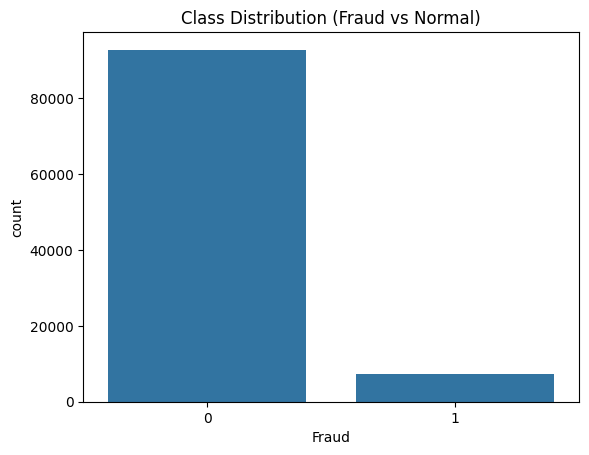

In [ ]:
# ==============================
# 3. BASIC EDA
# ==============================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# Class distribution
plt.figure()
sns.countplot(x='Fraud', data=df)
plt.title("Class Distribution (Fraud vs Normal)")
plt.show()


In [ ]:
# ==============================
# 4. DATA CLEANING
# ==============================

# Remove duplicates
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Handle missing values
df = df.ffill().bfill()

After removing duplicates: (100000, 16)


C:\Users\Shivam\AppData\Local\Temp\ipykernel_4980\3824429167.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
# ==============================
# 5. FEATURE ENGINEERING / ENCODING
# ==============================

# Encode categorical columns
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

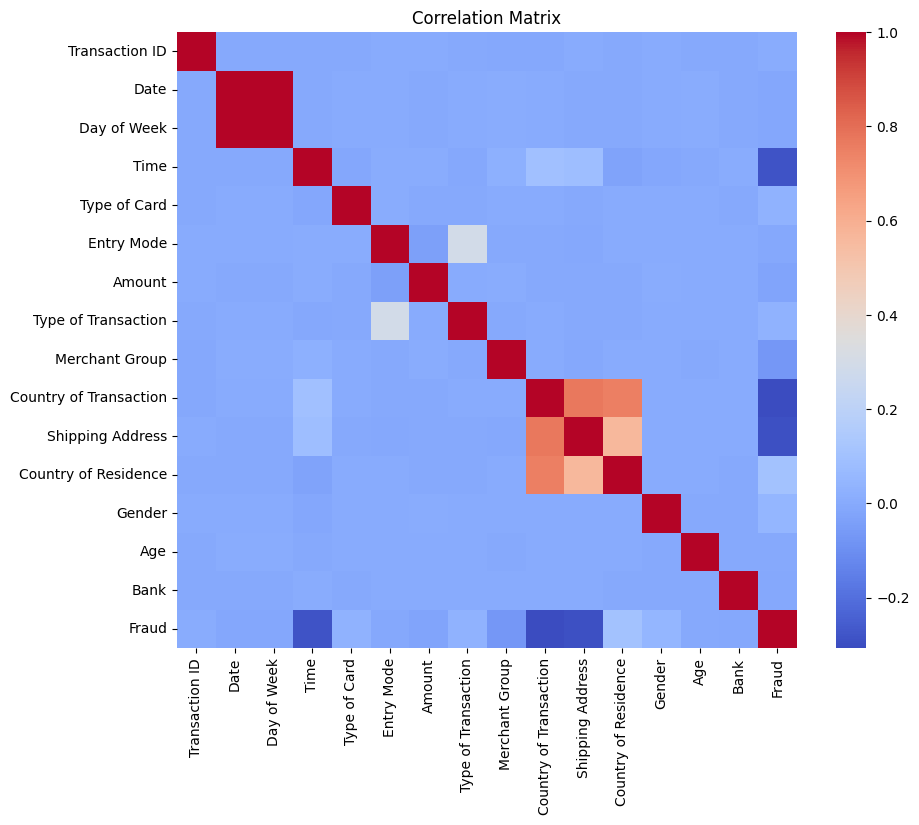

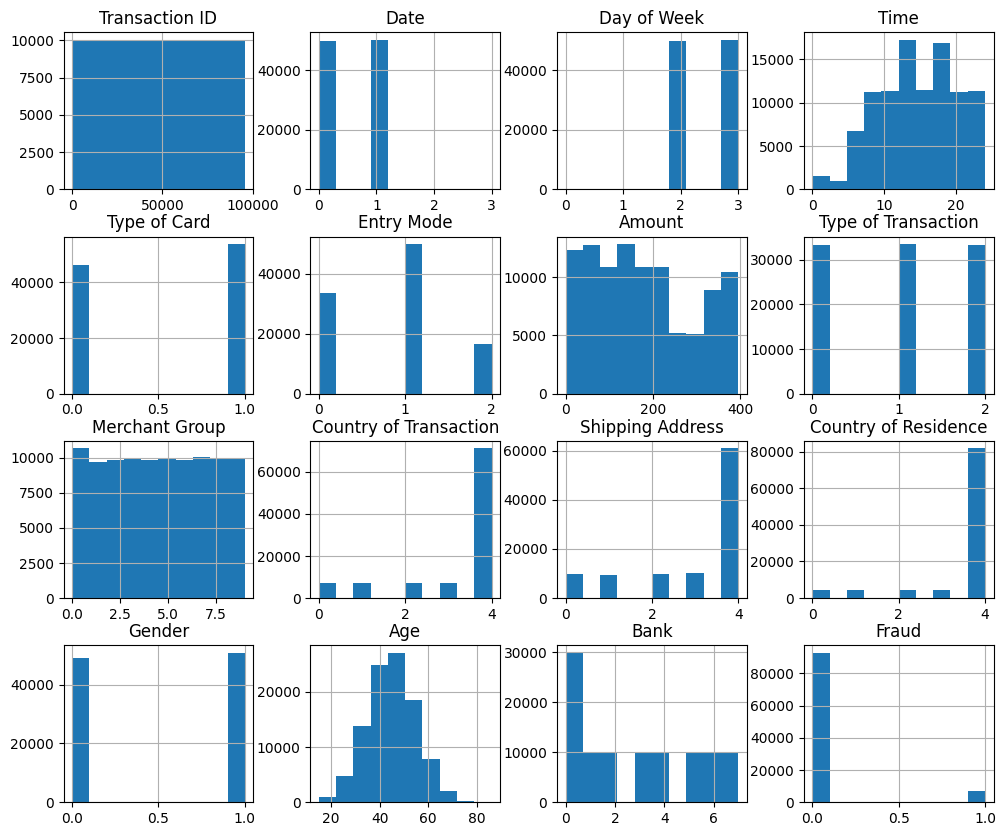

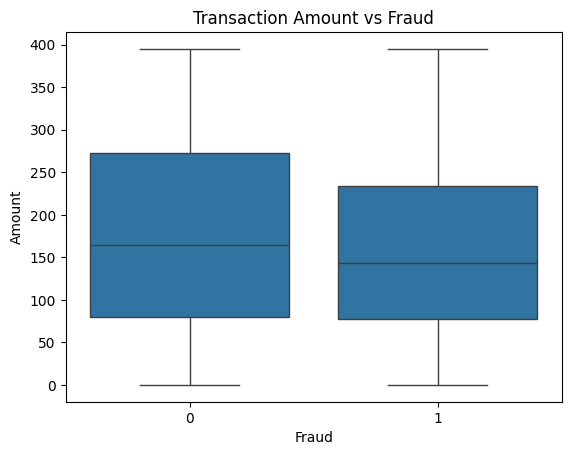

In [ ]:
# ==============================
# 6. ADVANCED EDA
# ==============================

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Distribution of important features
df.hist(figsize=(12,10))
plt.show()

# Fraud vs Amount (if column exists)
if 'Amount' in df.columns:
    plt.figure()
    sns.boxplot(x='Fraud', y='Amount', data=df)
    plt.title("Transaction Amount vs Fraud")
    plt.show()

In [ ]:
# ==============================
# 7. SPLIT FEATURES & TARGET
# ==============================

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

In [ ]:
# ==============================
# 8. SCALING
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# ==============================
# 9. HANDLE IMBALANCE (SMOTE)
# ==============================

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("After SMOTE:", np.bincount(y_res))

After SMOTE: [92805 92805]


In [ ]:
# ==============================
# 10. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


MODEL: Logistic Regression
Confusion Matrix:
[[17475  1116]
 [ 2108 16423]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     18591
           1       0.94      0.89      0.91     18531

    accuracy                           0.91     37122
   macro avg       0.91      0.91      0.91     37122
weighted avg       0.91      0.91      0.91     37122

ROC AUC Score: 0.9131078123894761
Accuracy: 0.9132 | Precision: 0.9364 | Recall: 0.8862 | F1: 0.9106


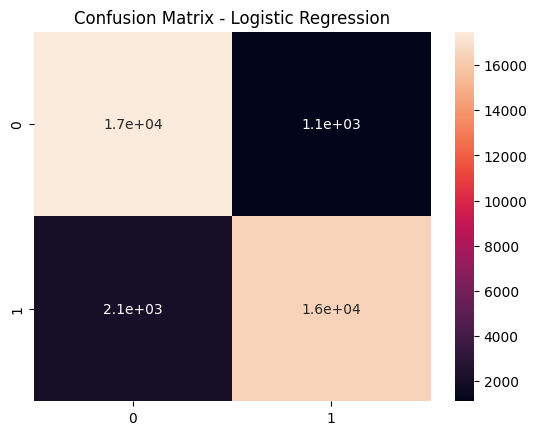


MODEL: Decision Tree
Confusion Matrix:
[[18143   448]
 [  308 18223]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18591
           1       0.98      0.98      0.98     18531

    accuracy                           0.98     37122
   macro avg       0.98      0.98      0.98     37122
weighted avg       0.98      0.98      0.98     37122

ROC AUC Score: 0.9796407603718211
Accuracy: 0.9796 | Precision: 0.9760 | Recall: 0.9834 | F1: 0.9797


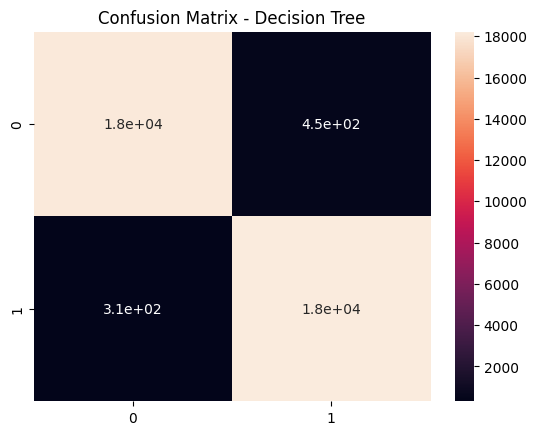


MODEL: Random Forest
Confusion Matrix:
[[18231   360]
 [  137 18394]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     18591
           1       0.98      0.99      0.99     18531

    accuracy                           0.99     37122
   macro avg       0.99      0.99      0.99     37122
weighted avg       0.99      0.99      0.99     37122

ROC AUC Score: 0.9866213872027759
Accuracy: 0.9866 | Precision: 0.9808 | Recall: 0.9926 | F1: 0.9867


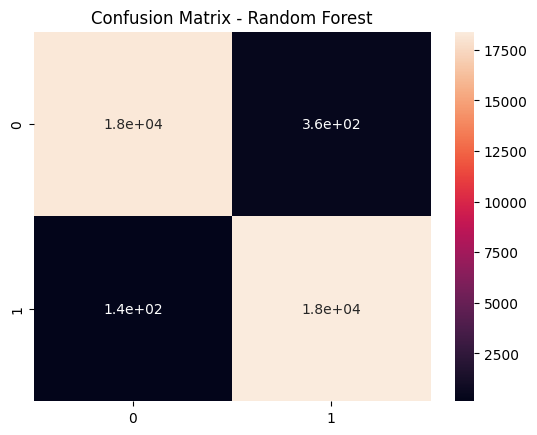


Final Model Performance Summary:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9866     0.9808  0.9926    0.9867   0.9866
      Decision Tree    0.9796     0.9760  0.9834    0.9797   0.9796
Logistic Regression    0.9132     0.9364  0.8862    0.9106   0.9131


In [ ]:
# ==============================
# 11. MODEL TRAINING
# ==============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

metrics_summary = []

for name, model in models.items():

    print("\n==============================")
    print("MODEL:", name)
    print("==============================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("ROC AUC Score:", roc_auc)
    print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

    metrics_summary.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    # Heatmap
    plt.figure()
    sns.heatmap(cm, annot=True)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

summary_df = pd.DataFrame(metrics_summary).sort_values(by="ROC-AUC", ascending=False)
print("\nFinal Model Performance Summary:")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

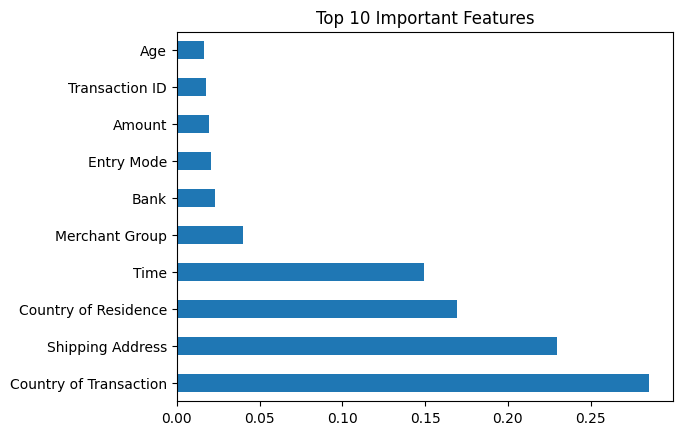

In [ ]:
# ==============================
# 12. FEATURE IMPORTANCE (RF)
# ==============================

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
# ==============================
# 13. OPTIONAL - ANN MODEL
# ==============================

import importlib

try:
    tf_models = importlib.import_module("tensorflow.keras.models")
    tf_layers = importlib.import_module("tensorflow.keras.layers")
    Sequential = tf_models.Sequential
    Dense = tf_layers.Dense

    ann = Sequential()
    ann.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
    ann.add(Dense(16, activation='relu'))
    ann.add(Dense(1, activation='sigmoid'))

    ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    ann.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
except ModuleNotFoundError:
    print("TensorFlow is not installed. Skipping optional ANN model cell.")

TensorFlow is not installed. Skipping optional ANN model cell.


In [ ]:
# ==============================
# 14. INTERACTIVE FRAUD PREDICTION
# ==============================

if "models" not in globals() or "Random Forest" not in models:
    raise ValueError("Please run the model training cell first.")

feature_columns = list(X.columns)
example_row = X.iloc[0].to_dict()
rf_model = models["Random Forest"]

print("\nProvide all transaction inputs and click Predict.")
print("Examples are pre-filled from a real row in your dataset.")

try:
    import ipywidgets as widgets
    from IPython.display import display

    input_widgets = {}
    for col in feature_columns:
        input_widgets[col] = widgets.FloatText(
            value=float(example_row[col]),
            description=str(col),
            layout=widgets.Layout(width='500px')
        )

    predict_btn = widgets.Button(description="Predict", button_style="primary")
    output_area = widgets.Output()

    def on_predict_clicked(_):
        with output_area:
            output_area.clear_output()
            user_values = {col: float(input_widgets[col].value) for col in feature_columns}
            user_df = pd.DataFrame([user_values], columns=feature_columns)
            user_scaled = scaler.transform(user_df)

            prediction = int(rf_model.predict(user_scaled)[0])
            if hasattr(rf_model, "predict_proba"):
                fraud_probability = float(rf_model.predict_proba(user_scaled)[0][1])
                print(f"Fraud probability: {fraud_probability:.4f}")

            print("Prediction: FRAUD" if prediction == 1 else "Prediction: NOT FRAUD")

    predict_btn.on_click(on_predict_clicked)

    display(widgets.VBox(list(input_widgets.values()) + [predict_btn, output_area]))

except ModuleNotFoundError:
    print("ipywidgets is not installed. Falling back to text prompts.")
    user_values = {}
    for col in feature_columns:
        while True:
            raw_val = input(f"Enter {col} (example: {example_row[col]}): ").strip()
            try:
                user_values[col] = float(raw_val)
                break
            except ValueError:
                print("Invalid input. Please enter a numeric value.")

    user_df = pd.DataFrame([user_values], columns=feature_columns)
    user_scaled = scaler.transform(user_df)
    prediction = int(rf_model.predict(user_scaled)[0])

    if hasattr(rf_model, "predict_proba"):
        fraud_probability = float(rf_model.predict_proba(user_scaled)[0][1])
        print(f"Fraud probability: {fraud_probability:.4f}")

    print("Prediction: FRAUD" if prediction == 1 else "Prediction: NOT FRAUD")


Enter all transaction inputs to predict fraud.
Note: Categorical fields are label-encoded, so enter numeric encoded values.

Input format examples (from an existing row):
- Transaction ID: e.g., 86389.0
- Date: e.g., 1.0
- Day of Week: e.g., 3.0
- Time: e.g., 19.0
- Type of Card: e.g., 1.0
- Entry Mode: e.g., 2.0
- Amount: e.g., 341.0
- Type of Transaction: e.g., 2.0
- Merchant Group: e.g., 2.0
- Country of Transaction: e.g., 4.0
- Shipping Address: e.g., 4.0
- Country of Residence: e.g., 4.0
- Gender: e.g., 1.0
- Age: e.g., 25.2
- Bank: e.g., 7.0


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings

# Silence the harmless pandas version warning to keep the terminal clean
warnings.filterwarnings('ignore', category=FutureWarning)

print("1. Loading data...")
df = pd.read_csv('CreditCardData.csv')

print("2. Cleaning and Preprocessing...")
# Drop columns that are completely unique or irrelevant to the prediction
columns_to_drop = ['Transaction ID', 'Date']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Clean the 'Amount' column (Remove '£' and commas, convert to float)
df['Amount'] = df['Amount'].astype(str).str.replace('£', '').str.replace(',', '').astype(float)

# THE FIX: Drop any rows that contain missing values (NaN) so SMOTE doesn't crash
df = df.dropna()

# Encode all remaining text/categorical columns into numbers
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le 

# Separate features and target
X = df.drop('Fraud', axis=1)
y = df['Fraud']

print("3. Splitting data (Fixing Data Leakage)...")
# Stratify ensures the 1% fraud ratio is maintained in both Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("4. Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("5. Applying SMOTE (Balancing the training data)...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("6. Training the Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_resampled, y_train_resampled)

print("7. Exporting Artifacts...")
joblib.dump(rf_model, 'fraud_rf_model.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')
joblib.dump(label_encoders, 'fraud_label_encoders.pkl')

print("✅ SUCCESS! Your AI engine is ready for the backend.")

1. Loading data...
2. Cleaning and Preprocessing...
3. Splitting data (Fixing Data Leakage)...
4. Scaling features...
5. Applying SMOTE (Balancing the training data)...
6. Training the Random Forest...
7. Exporting Artifacts...
✅ SUCCESS! Your AI engine is ready for the backend.


In [9]:
# ==============================
# 15. AGENTIC AI WRAPPER (GROQ)
# ==============================

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import os
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

# --- Hardcoded Groq API Key (as requested) ---
os.environ["GROQ_API_KEY"] = "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"

required_vars = ["df", "X", "X_test", "y", "y_test", "scaler", "rf_model"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        "Run the training/export cell first (Cell 15), then run this cell. Missing: "
        + ", ".join(missing_vars)
    )

def run_eda_tool(query: str) -> str:
    """Explore dataset and return fraud distribution and basic stats."""
    fraud_count = y.value_counts().to_dict()
    return (
        f"Dataset shape: {df.shape}\n"
        f"Fraud distribution: {fraud_count}\n"
        f"Basic Stats:\n{df.describe().to_string()}"
    )

def model_performance_tool(query: str) -> str:
    """Check trained Random Forest model accuracy and ROC-AUC score."""
    y_pred = rf_model.predict(scaler.transform(X_test))
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    return f"Accuracy: {acc:.4f}, ROC-AUC: {roc:.4f}"

def predict_fraud_tool(transaction_str: str) -> str:
    """Predict whether a transaction is fraud from comma-separated numeric values."""
    try:
        vals = list(map(float, transaction_str.strip().split(",")))
        if len(vals) != len(X.columns):
            return (
                f"Error: Expected {len(X.columns)} values, got {len(vals)}. "
                f"Required columns: {list(X.columns)}"
            )

        df_input = pd.DataFrame([vals], columns=X.columns)
        scaled_input = scaler.transform(df_input)
        pred = rf_model.predict(scaled_input)[0]
        prob = rf_model.predict_proba(scaled_input)[0][1]
        label = "FRAUD" if pred == 1 else "NOT FRAUD"
        return f"{label} | Probability: {prob:.4f}"
    except Exception as e:
        return f"Prediction error: {str(e)}"

def feature_importance_tool(query: str) -> str:
    """Return top 5 important features."""
    importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    top5 = importances.nlargest(5)
    return "Top 5 features: " + ", ".join([f"{feat} ({score:.4f})" for feat, score in top5.items()])

print("=" * 50)
print("RUNNING FRAUD DETECTION AGENT")
print("=" * 50)

# Build a valid sample transaction from schema
tx = ",".join(map(str, X.iloc[0].tolist()))

print("\nThought: I need to check model performance first")
print("Action: ModelPerformance")
obs1 = model_performance_tool("")
print(f"Observation: {obs1}")

print("\nThought: Now I should check feature importance")
print("Action: FeatureImportance")
obs2 = feature_importance_tool("")
print(f"Observation: {obs2}")

print("\nThought: Now predict fraud for the transaction")
print("Action: PredictFraud")
obs3 = predict_fraud_tool(tx)
print(f"Observation: {obs3}")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    groq_api_key=os.environ["GROQ_API_KEY"]
)

prompt = f"""You are a fraud detection assistant.
Using the observations below, write a concise final answer for a user.
Include:
1) model quality summary,
2) top feature takeaway,
3) risk interpretation of the prediction.

Observation 1 (ModelPerformance): {obs1}
Observation 2 (FeatureImportance): {obs2}
Observation 3 (PredictFraud): {obs3}
"""

final_answer = llm.invoke([HumanMessage(content=prompt)]).content

print("\nFinal Answer:")
print(final_answer)

RUNNING FRAUD DETECTION AGENT

Thought: I need to check model performance first
Action: ModelPerformance
Observation: Accuracy: 0.9826, ROC-AUC: 0.9188

Thought: Now I should check feature importance
Action: FeatureImportance
Observation: Top 5 features: Country of Transaction (0.2574), Shipping Address (0.2437), Country of Residence (0.1720), Time (0.1514), Amount (0.0602)

Thought: Now predict fraud for the transaction
Action: PredictFraud
Observation: NOT FRAUD | Probability: 0.0000

Final Answer:
**Final Answer:** 
The fraud detection model demonstrates high quality with an accuracy of 0.9826 and ROC-AUC of 0.9188. 
The top feature influencing the prediction is the **Country of Transaction**, indicating its significant role in determining fraud risk. 
Given the prediction of **NOT FRAUD** with a probability of 0.0000, the transaction is considered extremely low risk, suggesting it is highly unlikely to be fraudulent.
